#📌 Extracción

In [ ]:
import pandas as pd
import requests
import json
import numpy as np

# acceso a API
df = requests.get('https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')

# recuperar datos
resultado = json.loads(df.text)

# vista previa de df
df = pd.DataFrame(resultado)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
id_churn = df[['customerID', 'Churn']]
id_churn

customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

#concatenando para crear el df base

telecom_df = pd.concat([id_churn, customer, phone, internet, account], axis=1)
telecom_df.sample(4)

#renombrando columnas
telecom_df.rename(columns={
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'es_ciudadano_senior',
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'meses_en_empresa',
    'PhoneService': 'servicio_telefonico',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'tipo_internet',
    'OnlineSecurity': 'seguridad_online',
    'OnlineBackup': 'respaldo_online',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'tv_streaming',
    'StreamingMovies': 'peliculas_streaming',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'factura_electronica',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargos_mensuales',
    'Charges.Total': 'cargos_totales',
    'Churn': 'abandono'
}, inplace=True)

telecom_df.head()

telecom_df.columns

telecom_df.info()

#verificación que no existan datos null
telecom_df.isnull().sum()

#verificación de valores duplicados
print(telecom_df.duplicated().sum())

#verificando errores de formato
for col in ['id_cliente', 'abandono', 'genero', 'es_ciudadano_senior',
       'tiene_pareja', 'tiene_dependientes', 'meses_en_empresa',
       'servicio_telefonico', 'lineas_multiples', 'tipo_internet',
       'seguridad_online', 'respaldo_online', 'proteccion_dispositivo',
       'soporte_tecnico', 'tv_streaming', 'peliculas_streaming',
       'tipo_contrato', 'factura_electronica', 'metodo_pago',
       'cargos_mensuales', 'cargos_totales']:
    print(f"Valores únicos para la columna '{col}':")
    print(telecom_df[col].unique())
    print("-" * 20)

#limpieza columna id del cliente
telecom_df['id_cliente'] = telecom_df['id_cliente'].str.strip()
telecom_df['id_cliente'].sample(4)

#limpieza de la columna tipo_contrato
telecom_df['tipo_contrato'] = telecom_df['tipo_contrato'].str.lower()
telecom_df['tipo_contrato'] = telecom_df['tipo_contrato'].str.replace(r'\-', ' ', regex=True).str.strip()
telecom_df['tipo_contrato'].sample(4)

#liempaza de la columna metodo_pago
telecom_df['metodo_pago'] = telecom_df['metodo_pago'].str.lower()
telecom_df['metodo_pago'] = telecom_df['metodo_pago'].str.replace(r'\(|\)', '', regex=True).str.strip()
telecom_df['metodo_pago'].sample(4)

#Eliminando los espacios del la columna cargos totales
telecom_df['cargos_totales'] = telecom_df['cargos_totales'].replace(' ', np.nan)
#convirtiendo el tipo de dato
telecom_df['cargos_totales'] = pd.to_numeric(telecom_df['cargos_totales'], errors='coerce')
telecom_df.info()

telecom_df['cargos_totales'].isna().sum()

# Eliminar registros con cargos_totales faltantes
telecom_df = telecom_df.dropna(subset=['cargos_totales'])

# Verificación rápida
print(f"Número de registros después de limpieza: {len(telecom_df)}")

col_binario = ['abandono','tiene_pareja', 'tiene_dependientes', 'servicio_telefonico', 'factura_electronica']
telecom_df[col_binario].sample(4)

## Transformar columnas binarias en 'Yes' en 1 y 'No' en 0: la finalidad poder analizar estas columna

telecom_df.loc[:, col_binario] = telecom_df[col_binario].astype(str)
telecom_df.loc[:, col_binario] = telecom_df.loc[:, col_binario].replace({'Yes': 1, 'No': 0, '': np.nan})
telecom_df.loc[:, col_binario] = telecom_df.loc[:, col_binario].fillna(0)
telecom_df[col_binario].sample(4)

telecom_df[col_binario] = telecom_df[col_binario].astype(np.int64)
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7267 non-null   object 
 1   abandono                7267 non-null   object 
 2   genero                  7267 non-null   object 
 3   es_ciudadano_senior     7267 non-null   int64  
 4   tiene_pareja            7267 non-null   object 
 5   tiene_dependientes      7267 non-null   object 
 6   meses_en_empresa        7267 non-null   int64  
 7   servicio_telefonico     7267 non-null   object 
 8   lineas_multiples        7267 non-null   object 
 9   tipo_internet           7267 non-null   object 
 10  seguridad_online        7267 non-null   object 
 11  respaldo_online         7267 non-null   object 
 12  proteccion_dispositivo  7267 non-null   object 
 13  soporte_tecnico         7267 non-null   object 
 14  tv_streaming            7267 non-null   

/tmp/ipython-input-2620817503.py:97: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_df.loc[:, col_binario] = telecom_df.loc[:, col_binario].replace({'Yes': 1, 'No': 0, '': np.nan})
/tmp/ipython-input-2620817503.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_df.loc[:, col_binario] = telecom_df.loc[:, col_binario].fillna(0)


#📊 Carga y análisis

In [ ]:
#creando la columna cuentas_diarias
telecom_df['cuentas_diarias'] = telecom_df['cargos_mensuales']/30
telecom_df[['cargos_mensuales', 'cuentas_diarias']].sample(4)

#análisis descriptivo
telecom_df.describe()



,abandono,es_ciudadano_senior,tiene_pareja,tiene_dependientes,meses_en_empresa,servicio_telefonico,factura_electronica,cargos_mensuales,cargos_totales,cuentas_diarias
count,7256.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.257580,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158514
std,0.437332,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004191
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


# Distribución de evasión

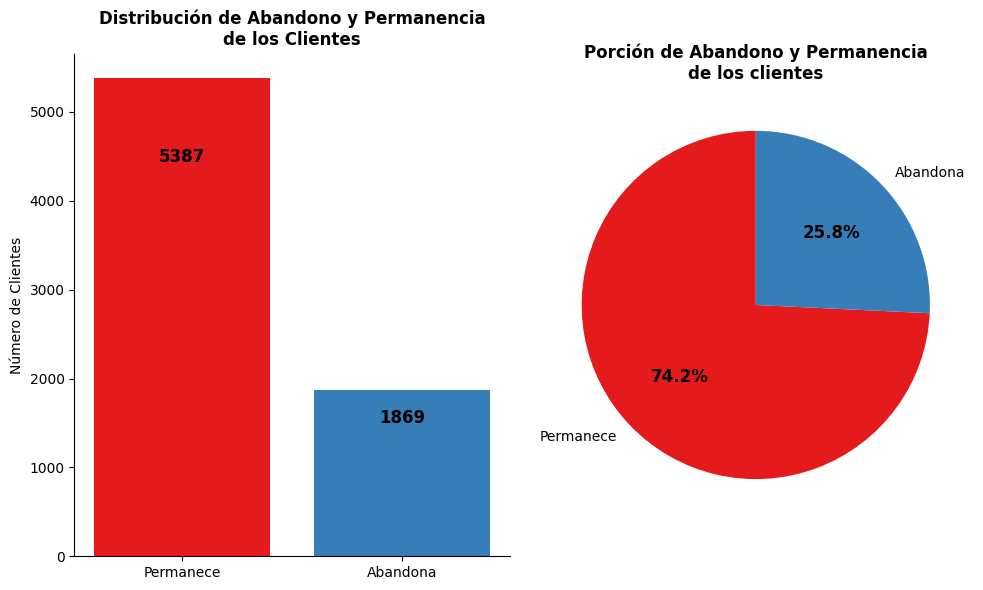

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

abandono_counts = telecom_df["abandono"].value_counts().sort_index()
abandono_props = telecom_df["abandono"].value_counts(normalize=True).sort_index()
labels = ["Permanecen", "Abandonan"]
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
colors = sns.color_palette("Set1")

# Gráfico de barras
bars = axs[0].bar(
    abandono_counts.index.map({0: 'Permanece', 1: 'Abandona'}),
    abandono_counts.values,
    color=colors
)

for ax in axs.flat:
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

axs[0].set_title('Distribución de Abandono y Permanencia\nde los Clientes', fontsize=12, weight='bold', loc='center')
axs[0].set_ylabel('Número de Clientes')

# Texto dentro de las barras
for bar in bars:
    height = bar.get_height()
    axs[0].text(
        bar.get_x() + bar.get_width() / 2,
        height /1.2,
        f'{height:.0f}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black')

axs[0].grid(False)

#gráfico de pastel
def custom_autopct(pct):
    return f'{pct:.1f}%'

wedges, texts, autotexts = axs[1].pie(
    abandono_counts.values,
    labels=abandono_counts.index.map({0: 'Permanece', 1: 'Abandona'}),
    autopct=custom_autopct,
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10})


for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axs[1].set_title('Porción de Abandono y Permanencia\nde los clientes', fontsize=12, weight='bold', loc='center')

plt.tight_layout()
plt.show()

# Recuento de evasión por variables categóricas


Análisis para: genero
        % No Abandono  % Abandono
genero                           
Female      73.822135   26.177865
Male        74.652494   25.347506

Análisis para: tipo_contrato
                % No Abandono  % Abandono
tipo_contrato                            
month to month      58.676654   41.323346
one year            89.064559   10.935441
two year            97.230237    2.769763

Análisis para: metodo_pago
                         % No Abandono  % Abandono
metodo_pago                                       
bank transfer automatic      83.742911   16.257089
credit card automatic        85.194639   14.805361
electronic check             56.196319   43.803681
mailed check                 81.412191   18.587809

Análisis para: tipo_internet
               % No Abandono  % Abandono
tipo_internet                           
DSL                81.514297   18.485703
Fiber optic        59.443402   40.556598
No                 92.825397    7.174603


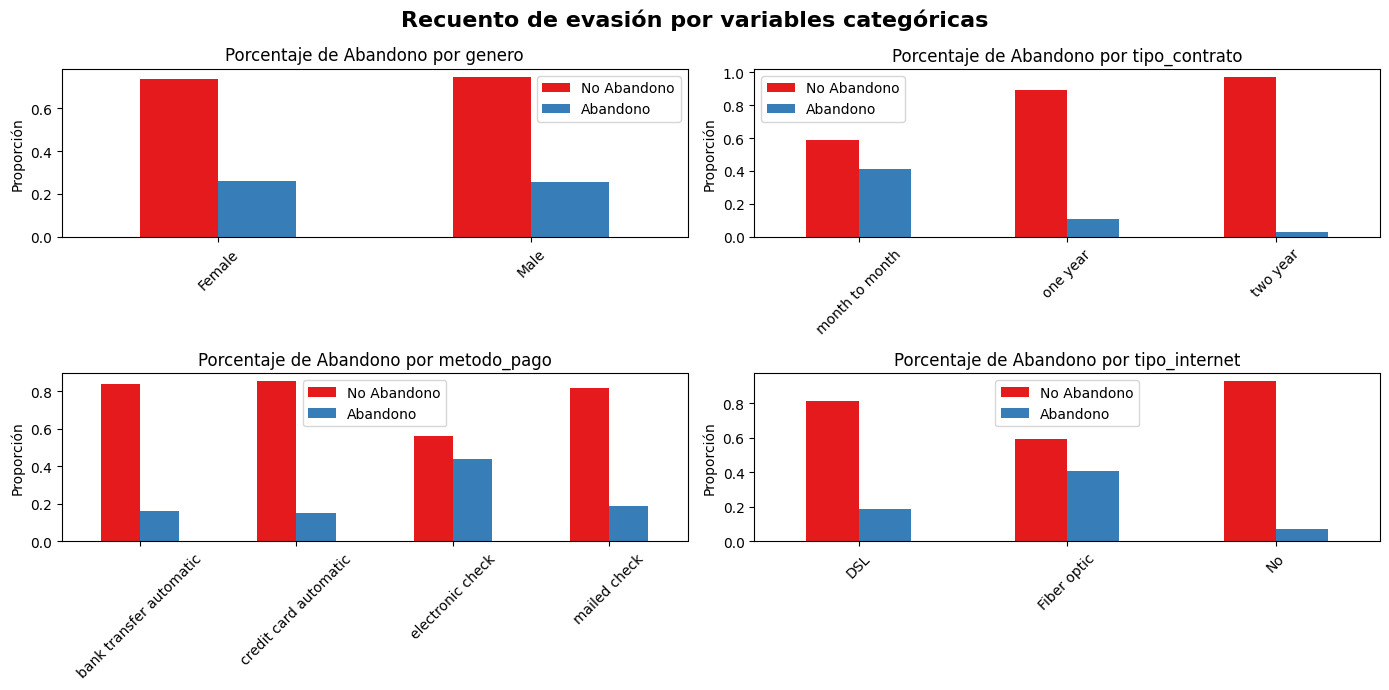

In [ ]:
# Función auxiliar para ver distribución de abandono por cada categoría
def analizar_evasion_por_categoria(df, columna):
    cruzado = pd.crosstab(df[columna], df['abandono'], normalize='index') * 100
    cruzado.columns = ['% No Abandono', '% Abandono']
    print(f'\nAnálisis para: {columna}')
    print(cruzado)
    return cruzado

# Variables categóricas a analizar
categoricas = ['genero', 'tipo_contrato', 'metodo_pago', 'tipo_internet']

# Aplicar análisis
resultados = {}
for cat in categoricas:
    resultados[cat] = analizar_evasion_por_categoria(telecom_df, cat)

### GRAFICO

# Configuración de subplots: 2 columnas por fila
fig, axes = plt.subplots(nrows=(len(categoricas) + 1) // 2, ncols=2, figsize=(14, 7))
axes = axes.flatten()
colors = sns.color_palette("Set1")

# Crear cada gráfico en su subplot
for i, cat in enumerate(categoricas):
    cruzado = pd.crosstab(telecom_df[cat], telecom_df['abandono'], normalize='index')
    cruzado.plot(kind='bar', ax=axes[i], color=colors)

    axes[i].set_title(f'Porcentaje de Abandono por {cat}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proporción')
    axes[i].legend(['No Abandono', 'Abandono'])
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Recuento de evasión por variables categóricas', fontsize=16, weight='bold', ha='center')

plt.tight_layout()
plt.show()

# Análisis de evasión en columnas binarias


Análisis para: es_ciudadano_senior
                     % No Abandono  % Abandono
es_ciudadano_senior                           
No                       77.066184   22.933816
Sí                       59.729272   40.270728

Análisis para: tiene_pareja
              % No Abandono  % Abandono
tiene_pareja                           
No                67.974380   32.025620
Sí                80.934739   19.065261

Análisis para: tiene_dependientes
                    % No Abandono  % Abandono
tiene_dependientes                           
No                      69.661817   30.338183
Sí                      84.976959   15.023041

Análisis para: servicio_telefonico
                     % No Abandono  % Abandono
servicio_telefonico                           
No                       75.886525   24.113475
Sí                       74.065028   25.934972

Análisis para: factura_electronica
                     % No Abandono  % Abandono
factura_electronica                           
No            

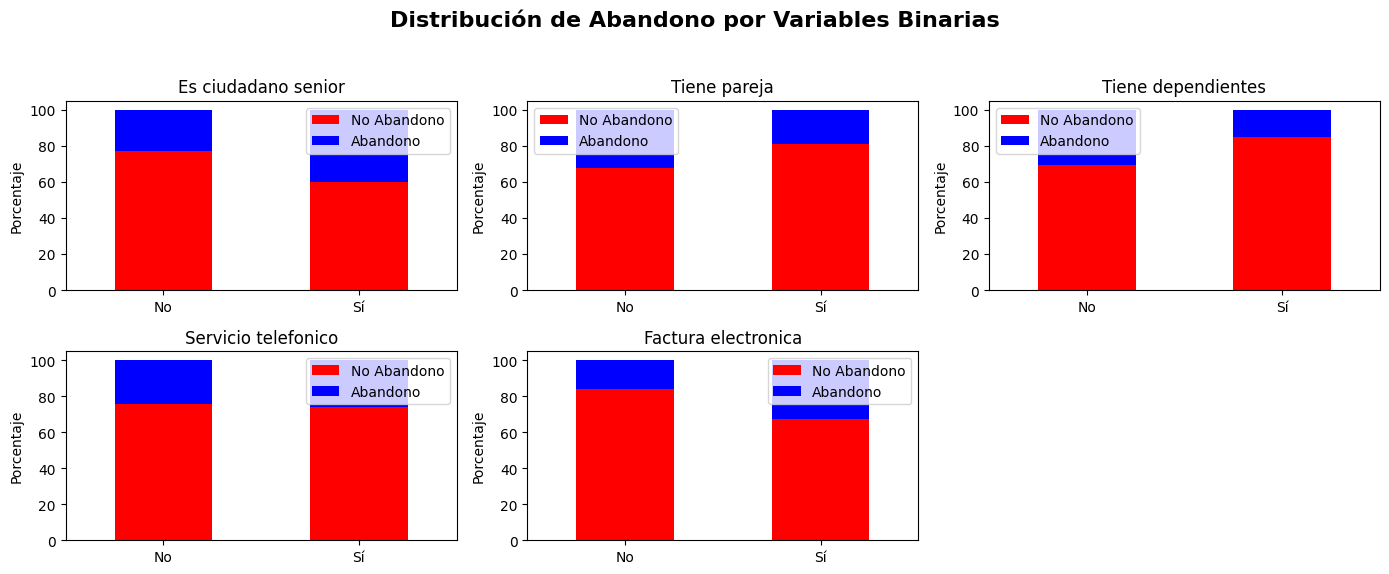

In [ ]:
binarias = ['es_ciudadano_senior', 'tiene_pareja', 'tiene_dependientes', 'servicio_telefonico', 'factura_electronica']
def analizar_evasion_binarias(df, columna):
    # Mapeo opcional para mejor legibilidad (0 = No, 1 = Sí)
    df_temp = df.copy()
    df_temp[columna] = df_temp[columna].map({1: 'Sí', 0: 'No'})

    cruzado = pd.crosstab(df_temp[columna], df_temp['abandono'], normalize='index') * 100
    cruzado.columns = ['% No Abandono', '% Abandono']

    print(f'\nAnálisis para: {columna}')
    print(cruzado)
    return cruzado

# Resultados por columna binaria
resultados_binarios = {}
for col in binarias:
    resultados_binarios[col] = analizar_evasion_binarias(telecom_df, col)

### GRAFICO

# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for idx, col in enumerate(binarias):
    df_temp = telecom_df.copy()
    df_temp[col] = df_temp[col].map({1: 'Sí', 0: 'No'})

    cruzado = pd.crosstab(df_temp[col], df_temp['abandono'], normalize='index') * 100
    cruzado.columns = ['No Abandono', 'Abandono']

    cruzado.plot(kind='bar', stacked=True, color=['red', 'blue'], ax=axes[idx])
    axes[idx].set_title(f'{col.replace("_", " ").capitalize()}')
    axes[idx].set_ylabel('Porcentaje')
    axes[idx].set_xlabel('')
    axes[idx].legend(loc='best')
    axes[idx].tick_params(axis='x', rotation=0)

# Eliminar subplot vacío
if len(binarias) < len(axes):
    for j in range(len(binarias), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Distribución de Abandono por Variables Binarias', fontsize=16, weight='bold', ha='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Conteo de evasión por variables numéricas

In [ ]:
numericas = ['meses_en_empresa', 'cargos_mensuales', 'cargos_totales', 'cuentas_diarias']
def analizar_evasion_numericas(df, columnas, bins=4):

    resultados = {}

    for col in columnas:
        # Crear intervalos (bins)
        df[f'{col}_bin'] = pd.qcut(df[col], q=bins, duplicates='drop')

        # Tabla cruzada
        cruzado = pd.crosstab(df[f'{col}_bin'], df['abandono'], normalize='index') * 100
        cruzado.columns = ['% No Abandono', '% Abandono']

        print(f'\nAnálisis por rangos para: {col}')
        print(cruzado)

        resultados[col] = cruzado

    return resultados


resultados_numericas = analizar_evasion_numericas(telecom_df, numericas, bins=5)

### GRAFICO

import plotly.express as px


def graficar_barras_abandono_interactivo(df, columnas, bins=10):
    datos_plot = []

    for col in columnas:
        # Crear bins para la columna numérica
        df_temp = df.copy()
        df_temp[f'{col}_bin'] = pd.qcut(df[col], q=bins, duplicates='drop')

        # Convertir bin a string para evitar error al exportar
        df_temp[f'{col}_bin'] = df_temp[f'{col}_bin'].astype(str)

        # Calcular % de abandono agrupado por bin
        resumen = df_temp.groupby(f'{col}_bin', observed=True)['abandono'].mean().reset_index()
        resumen['abandono'] = resumen['abandono'] * 100
        resumen['variable'] = col

        resumen = resumen.rename(columns={f'{col}_bin': 'rango', 'abandono': 'porcentaje_abandono'})
        datos_plot.append(resumen)

    datos_todos = pd.concat(datos_plot)

    # Gráfico interactivo de barras agrupadas
    plotly_fig = px.bar(
        datos_todos,
        x='rango',
        y='porcentaje_abandono',
        color='variable',
        barmode='group',
        title='Porcentaje de abandono según variables numéricas',
        labels={'rango': 'Rango de valor', 'porcentaje_abandono': '% de abandono', 'variable': 'Variable'}
    )

    plotly_fig.update_layout(
        width=900,
        height=500,
        xaxis_tickangle=-45,
        template='plotly_white',
        font=dict(family='Arial', size=14, color='black')
    )

    plotly_fig.show()
    return plotly_fig

# Llamar la función
numericas = ['meses_en_empresa', 'cargos_mensuales', 'cargos_totales', 'cuentas_diarias']
plotly_figure_for_saving = graficar_barras_abandono_interactivo(telecom_df, numericas)

# Guardar como archivo
output_path = '/content/telecomx_evasion_clientes.html'
plotly_figure_for_saving.write_html(output_path)


Análisis por rangos para: meses_en_empresa
                      % No Abandono  % Abandono
meses_en_empresa_bin                           
(0.999, 6.0]              48.590164   51.409836
(6.0, 20.0]               67.456446   32.543554
(20.0, 40.0]              78.305785   21.694215
(40.0, 60.0]              84.924623   15.075377
(60.0, 72.0]              93.590627    6.409373

Análisis por rangos para: cargos_mensuales
                      % No Abandono  % Abandono
cargos_mensuales_bin                           
(18.249, 25.05]           91.114149    8.885851
(25.05, 58.7]             75.763889   24.236111
(58.7, 79.1]              71.114168   28.885832
(79.1, 94.3]              64.872326   35.127674
(94.3, 118.75]            68.206897   31.793103

Análisis por rangos para: cargos_totales
                    % No Abandono  % Abandono
cargos_totales_bin                           
(18.799, 266.6]         55.509642   44.490358
(266.6, 939.7]          72.019297   27.980703
(939.7, 2033.8

# Mapa de calor de correlaciones (para variables numéricas)

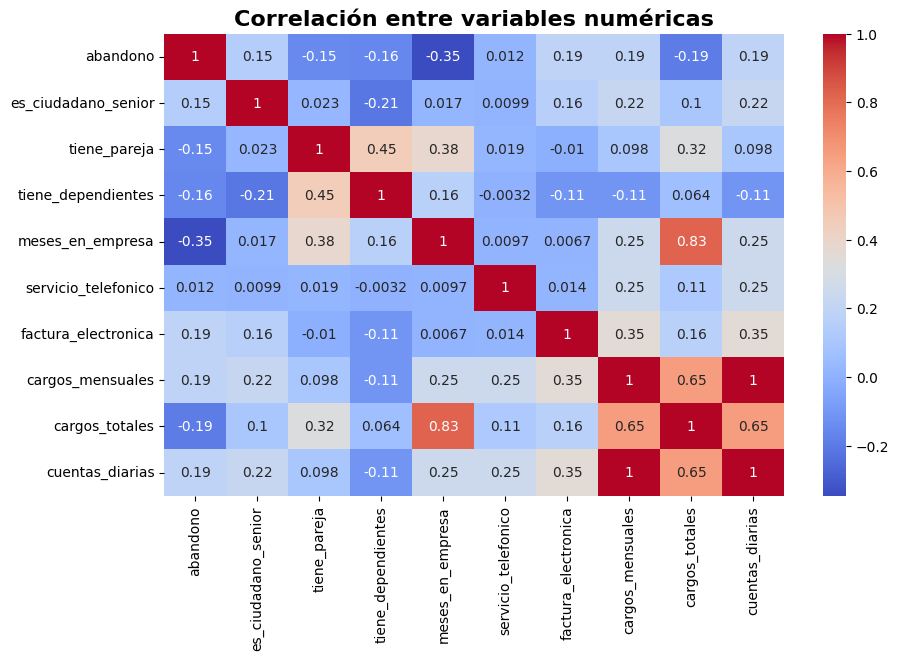

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(telecom_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas", fontsize=16, weight='bold', ha='center')
plt.show()

#📄Informe final

# 1.   Introducción

El presente análisis tiene como objetivo comprender los factores que influyen en la evasión de clientes (abandono) dentro de la empresa de telecomunicaciones. La pérdida de clientes representa un desafío significativo para la sostenibilidad y el crecimiento de la compañía, ya que adquirir nuevos clientes suele ser más costoso que retener a los existentes.

Mediante el análisis de datos históricos de clientes, se busca identificar patrones de comportamiento que puedan ayudar a prever la evasión y tomar medidas estratégicas que fomenten la retención de clientes.

# 2.   Limpieza y Tratamiento de Datos

**Para preparar los datos y garantizar su calidad, se llevaron a cabo los siguientes pasos:**

+ Importación de datos desde una API de Telecom X, los datos están disponibles en formato JSON.

+ Eliminación de espacios en nombres de columnas para facilitar la manipulación del DataFrame.

+ Conversión de tipos de datos, por ejemplo: transformar la columnas a tipo numérico, corrigiendo errores de formato.

+ Eliminación de registros nulos o vacíos, especialmente aquellos sin valor en columnas críticas como ID_Cliente.

+ Revisión y eliminación de duplicados para evitar distorsiones en el análisis.

+ Análisis de valores únicos y consistencia en categorías (por ejemplo, estandarización de las respuestas en campos como Churn y Genero).

# 3.   Análisis Exploratorio de Datos

**Se realizó un análisis estadístico y visual para entender mejor los datos y detectar patrones asociados al churn.**

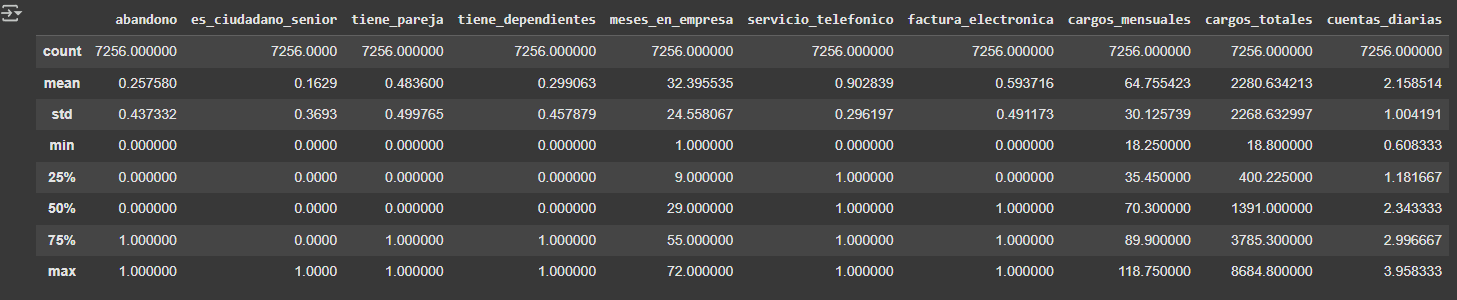

# 4.   Conclusiones e Insights

**A partir del análisis realizado, se destacan los siguientes hallazgos clave:**

+ El tipo de contrato mensual es el más propenso a la cancelación, lo que sugiere menor compromiso del cliente.

+ Los clientes con contratos mensuales y pagos electrónicos son más propensos a abandonar.

+ La edad y el hecho de vivir solos o sin dependientes también influyen en la evasión.

+ Clientes nuevos o con bajo uso de servicios son los más vulnerables a cancelar.

+ La factura electrónica podría estar asociada con un perfil de cliente más crítico o digitalizado, con menor lealtad.

+ Métodos de pago automáticos podrían estar relacionados con una menor evasión, posiblemente por conveniencia.

+ La lealtad del cliente aumenta con el tiempo, por lo que retener clientes en los primeros meses es esencial.

+ El gasto total elevado no garantiza permanencia, lo que indica que se debe trabajar en la percepción del valor ofrecido.

# 5.   Recomendaciones

**Con base en los hallazgos anteriores, se proponen las siguientes acciones estratégicas:**

+ Fidelizar clientes nuevos, Ofrecer incentivos para contratos a largo plazo, como descuentos o beneficios exclusivos, para reducir la tasa de evasión en clientes con contratos mensuales.

+ Mejorar la experiencia del cliente en los primeros meses mediante atención proactiva y servicios personalizados.

+ Ofrecer asesoría personalizada a adultos mayores para reducir evasión por falta de uso o dificultades técnicas.

+ Promover servicios adicionales que aumenten la vinculación del cliente con la marca.

+ Establecer campañas dirigidas a clientes en riesgo de abandono, detectando perfiles comunes de cancelación.

+ Revisar la estrategia de precios y percepción de valor, especialmente en segmentos con alto gasto pero alta tasa de evasión.

+ Investigar la experiencia digital de los usuarios que reciben factura electrónica para detectar fricciones.